##<p><strong>Paso: Librerias y cargar datos</strong></br>

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn import metrics
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [202]:
archivo=('Base_Pruebas_INTNEG (FUGA).xlsx')
df=pd.read_excel(archivo)

##<p><strong>Paso: EDA (exploracion de los datos)</strong></br>

In [203]:
df = df.drop('CUENTA_CLIENTE', axis=1)
df.describe()

,SK_OFICINA,SK_CAMPAÑA,TASA,MORA,GARANTIA,SALDO_CAPITAL,MONTO_DESEMBOLSADO,NUMERO_CUOTAS,NUMERO_CUOTAS_PAGADAS,CUOTAS_RESTANTES,FECHA_DESEMBOLSO,RT_SALDO_DESEMBOLSO,IND_AGRO,COD_MUNICIPIO_CLIENTE,NOTA_CLIENTE,ENTIDADES_ALERTA,CLIENTE_DIGITAL,MARCA_FUGA
count,126369.000000,126369.000000,1.263690e+05,126369.000000,126369.000000,1.263690e+05,1.263690e+05,126369.000000,126369.000000,126369.000000,126369.000000,1.263690e+05,126369.000000,126369.000000,126369.000000,4475.000000,126369.000000,126369.000000
mean,329.961185,15.539824,1.343051e+05,7.556766,0.349231,5.233120e+06,7.299837e+06,25.941386,10.738781,15.205224,45012.412443,5.870337e+10,0.269283,36614.233190,4.000641,1.196201,0.449082,0.184808
std,103.830472,50.880975,2.401381e+06,34.241204,0.476729,7.912977e+06,9.502779e+06,12.685608,9.215209,11.043194,302.483206,4.726465e+12,0.443589,27504.782899,1.529752,0.507815,0.497403,0.388143
min,202.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,1.391693e+04,0.000000,0.000000,0.000000,42724.000000,0.000000e+00,0.000000,-8888.000000,0.000000,1.000000,0.000000,0.000000
25%,261.000000,0.000000,4.340000e+01,0.000000,0.000000,1.456958e+06,2.734480e+06,18.000000,4.000000,6.000000,44873.000000,4.756405e-01,0.000000,13001.000000,3.000000,1.000000,0.000000,0.000000
50%,312.000000,0.000000,4.720000e+01,0.000000,0.000000,3.145746e+06,5.058560e+06,24.000000,9.000000,13.000000,45075.000000,7.348230e-01,0.000000,25086.000000,5.000000,1.000000,0.000000,0.000000
75%,362.000000,0.000000,5.111000e+01,0.000000,1.000000,5.984351e+06,8.134612e+06,36.000000,15.000000,23.000000,45239.000000,9.007221e-01,1.000000,66440.000000,5.000000,1.000000,1.000000,0.000000
max,643.000000,266.000000,5.536687e+07,1845.000000,1.000000,1.560000e+08,1.560000e+08,145.000000,111.000000,126.000000,45381.000000,8.365287e+14,1.000000,99524.000000,5.000000,6.000000,1.000000,1.000000


In [204]:
df.dtypes

SK_OFICINA                 int64
OFICINA                   object
ZONA                      object
TERRITORIAL               object
SK_CAMPAÑA                 int64
TASA                     float64
MORA                       int64
RANGO_MORA                object
CALIFICACION              object
GARANTIA                   int64
SALDO_CAPITAL            float64
MONTO_DESEMBOLSADO       float64
NUMERO_CUOTAS              int64
NUMERO_CUOTAS_PAGADAS      int64
CUOTAS_RESTANTES           int64
FECHA_DESEMBOLSO           int64
RT_SALDO_DESEMBOLSO      float64
GRUPO_RIESGO              object
GENERO                    object
AMBITO                    object
IND_AGRO                   int64
COD_MUNICIPIO_CLIENTE      int64
MUNICIPIO_CLIENTE         object
RANGO_EDAD                object
NOTA_CLIENTE               int64
CLASIFICACION             object
ENTIDADES_ALERTA         float64
CLIENTE_DIGITAL            int64
MARCA_CLIENTE             object
MARCA_FUGA                 int64
dtype: obj

In [205]:
df.groupby('MARCA_FUGA').size()

MARCA_FUGA
0    103015
1     23354
dtype: int64

In [206]:
df['FECHA_DESEMBOLSO'] = pd.to_datetime(df['FECHA_DESEMBOLSO'], unit='D', origin='1899-12-30')

In [207]:
df['CALIFICACION'] = df['CALIFICACION'].str.strip()
df['CALIFICACION'] = df['CALIFICACION'].astype('string')

df['MARCA_CLIENTE'] = df['MARCA_CLIENTE'].str.strip()
df['MARCA_CLIENTE'] = df['MARCA_CLIENTE'].astype('string')

df['GENERO'] = df['GENERO'].str.strip()
df['GENERO'] = df['GENERO'].astype('string')

In [208]:
df['CALIFICACION'].dtypes
# df['MARCA_CLIENTE'].dtypes
# df.dtypes

string[python]

In [209]:
df['GENERO'].dtypes

string[python]

In [11]:
# NAN_EN_MARCA_FUGA = df[df['MARCA_FUGA'].isnull()]
# NAN_EN_MARCA_FUGA = df[df['MARCA_FUGA'].isna()]
# pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [15]:
# df.groupby('SALDO_CAPITAL').sum()

In [21]:
# resumen = df.groupby('OFICINA')['SALDO_CAPITAL'].sum().reset_index()
# resumen

# resumen = df.groupby('OFICINA')['CUOTAS_RESTANTES'].sum().reset_index()
# resumen
# resumen = df.groupby('OFICINA')['MONTO_DESEMBOLSADO'].sum().reset_index()
# resumen

# resumen = df.groupby('OFICINA')['MORA'].sum().reset_index()
# resumen


In [210]:
df2 = df.select_dtypes(include=['int64', 'float64','string'])

In [211]:
df2.describe(include='all')

,SK_OFICINA,SK_CAMPAÑA,TASA,MORA,CALIFICACION,GARANTIA,SALDO_CAPITAL,MONTO_DESEMBOLSADO,NUMERO_CUOTAS,NUMERO_CUOTAS_PAGADAS,CUOTAS_RESTANTES,RT_SALDO_DESEMBOLSO,GENERO,IND_AGRO,COD_MUNICIPIO_CLIENTE,NOTA_CLIENTE,ENTIDADES_ALERTA,CLIENTE_DIGITAL,MARCA_CLIENTE,MARCA_FUGA
count,126369.000000,126369.000000,1.263690e+05,126369.000000,126369,126369.000000,1.263690e+05,1.263690e+05,126369.000000,126369.000000,126369.000000,1.263690e+05,126369,126369.000000,126369.000000,126369.000000,4475.000000,126369.000000,126369,126369.000000
unique,NaN,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,NaN,NaN,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FEMENINO,NaN,NaN,NaN,NaN,NaN,1. PERFIL_BUEN_CLIENTE,NaN
freq,NaN,NaN,NaN,NaN,111429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71359,NaN,NaN,NaN,NaN,NaN,69796,NaN
mean,329.961185,15.539824,1.343051e+05,7.556766,NaN,0.349231,5.233120e+06,7.299837e+06,25.941386,10.738781,15.205224,5.870337e+10,NaN,0.269283,36614.233190,4.000641,1.196201,0.449082,NaN,0.184808
std,103.830472,50.880975,2.401381e+06,34.241204,NaN,0.476729,7.912977e+06,9.502779e+06,12.685608,9.215209,11.043194,4.726465e+12,NaN,0.443589,27504.782899,1.529752,0.507815,0.497403,NaN,0.388143
min,202.000000,0.000000,0.000000e+00,0.000000,NaN,0.000000,0.000000e+00,1.391693e+04,0.000000,0.000000,0.000000,0.000000e+00,NaN,0.000000,-8888.000000,0.000000,1.000000,0.000000,NaN,0.000000
25%,261.000000,0.000000,4.340000e+01,0.000000,NaN,0.000000,1.456958e+06,2.734480e+06,18.000000,4.000000,6.000000,4.756405e-01,NaN,0.000000,13001.000000,3.000000,1.000000,0.000000,NaN,0.000000
50%,312.000000,0.000000,4.720000e+01,0.000000,NaN,0.000000,3.145746e+06,5.058560e+06,24.000000,9.000000,13.000000,7.348230e-01,NaN,0.000000,25086.000000,5.000000,1.000000,0.000000,NaN,0.000000
75%,362.000000,0.000000,5.111000e+01,0.000000,NaN,1.000000,5.984351e+06,8.134612e+06,36.000000,15.000000,23.000000,9.007221e-01,NaN,1.000000,66440.000000,5.000000,1.000000,1.000000,NaN,0.000000


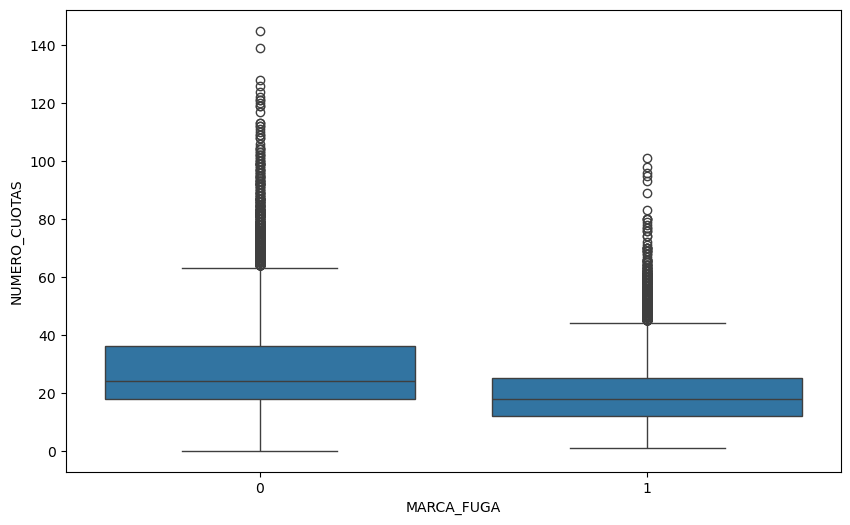

In [212]:
plt.figure(figsize=(10, 6))
# sns.boxplot(data=df, x='MARCA_FUGA', y='CUOTAS_RESTANTES')
# sns.boxplot(data=df, x='MARCA_FUGA', y='NUMERO_CUOTAS_PAGADAS')
sns.boxplot(data=df, x='MARCA_FUGA', y='NUMERO_CUOTAS')
# --- AQUÍ ESTÁ EL TRUCO ---
plt.ticklabel_format(style='plain', axis='y') 
# Si el saldo está en el eje X, cambia axis='y' por axis='x'
plt.show()

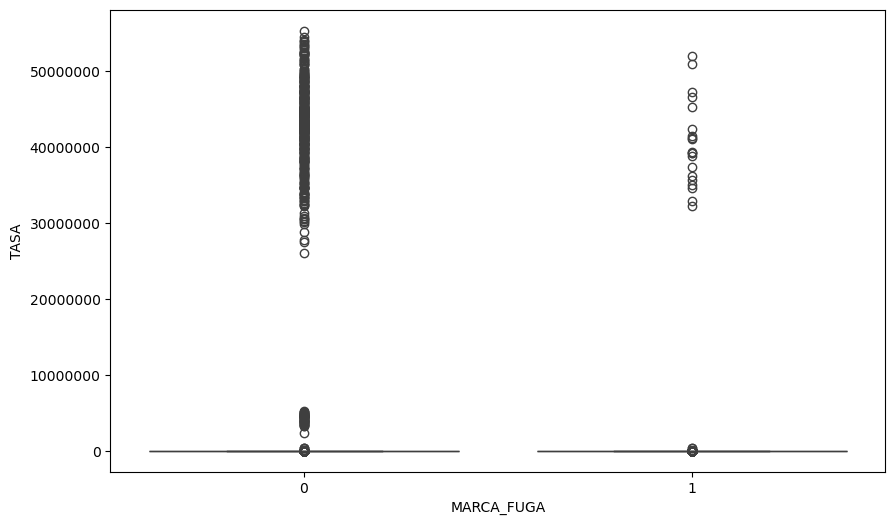

In [213]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='MARCA_FUGA', y='TASA')
# --- AQUÍ ESTÁ EL TRUCO ---
plt.ticklabel_format(style='plain', axis='y') 
# Si el saldo está en el eje X, cambia axis='y' por axis='x'
plt.show()

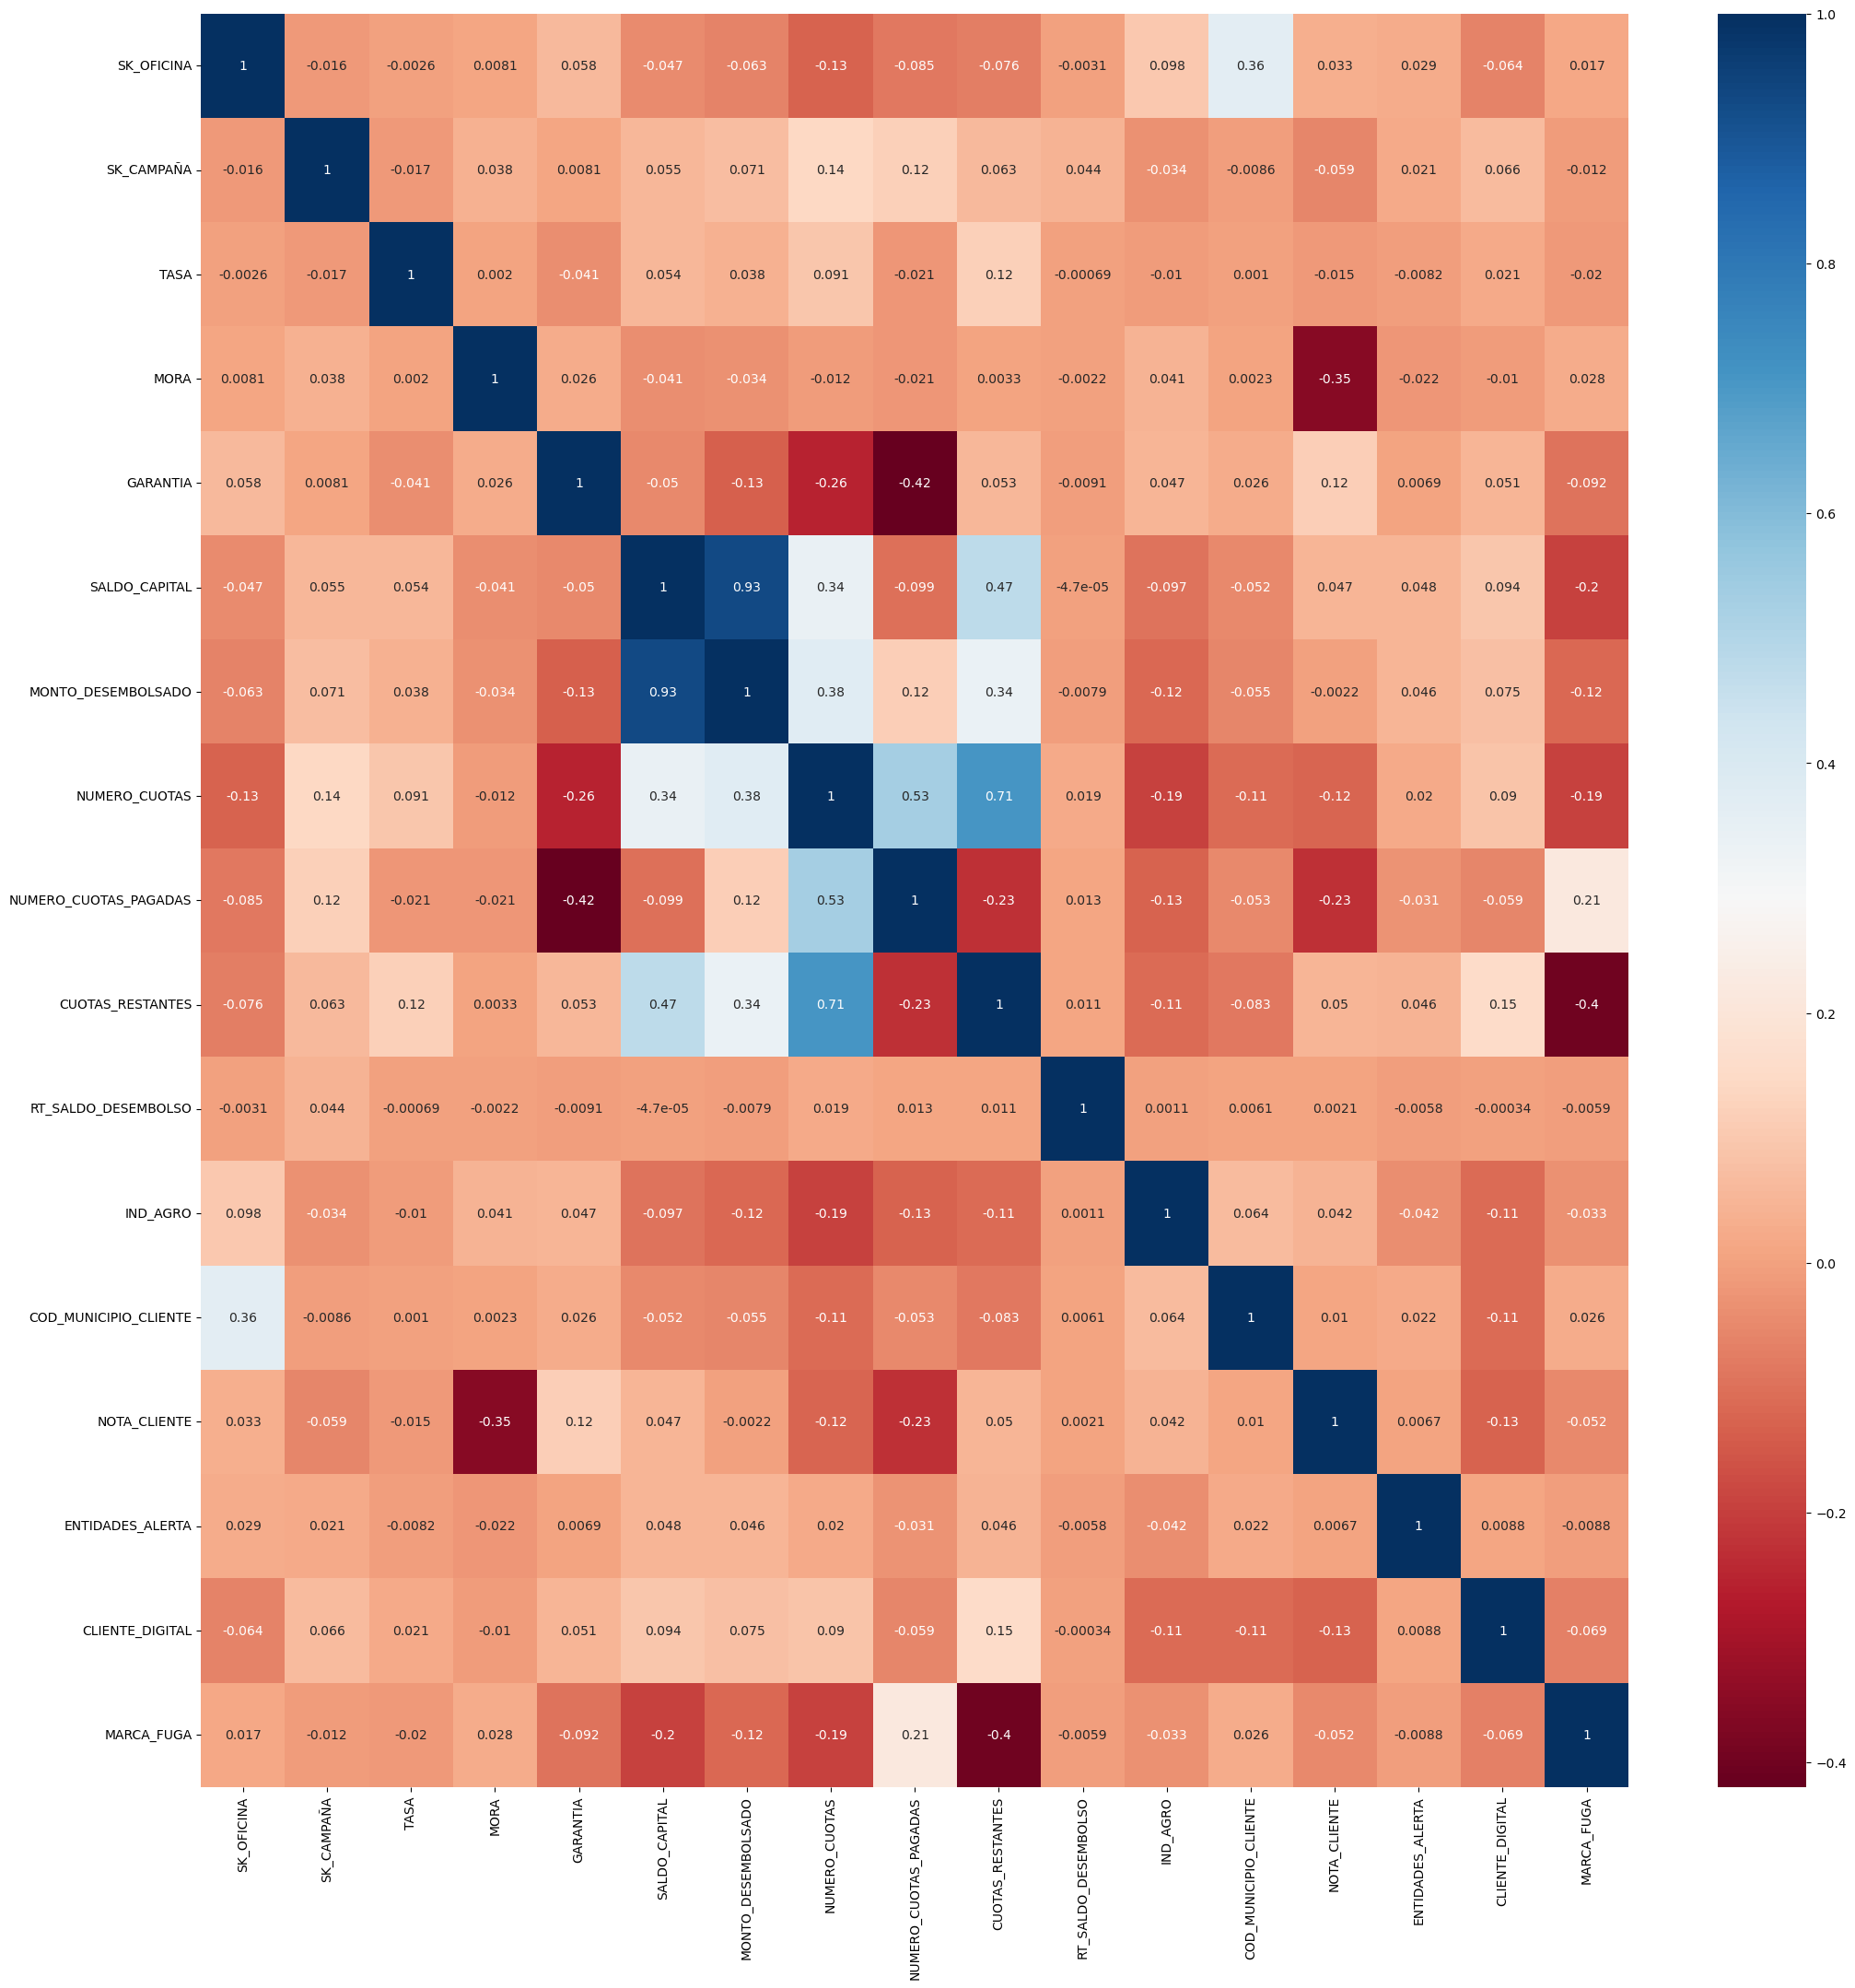

In [214]:
plt.figure(figsize=(25,25))
sns.heatmap(df2.select_dtypes(include=['int64', 'float64']).corr(), annot=True, cmap='RdBu')
plt.show()

##<p><strong>Paso: Preparar lo datos</strong></br>

In [215]:
df2['PORC_CUOTAS_PAGADAS'] = df2['NUMERO_CUOTAS_PAGADAS'] / df2['NUMERO_CUOTAS']
# df2['SALDO_RELATIVO'] = df2['SALDO_CAPITAL'] / df2['MONTO_DESEMBOLSADO']

# si 'PORC_CUOTAS_PAGADAS'] > 0.99 entocnes la deje como maximo 0.99
df2['PORC_CUOTAS_PAGADAS'] = df2['PORC_CUOTAS_PAGADAS'].clip(upper=0.99)


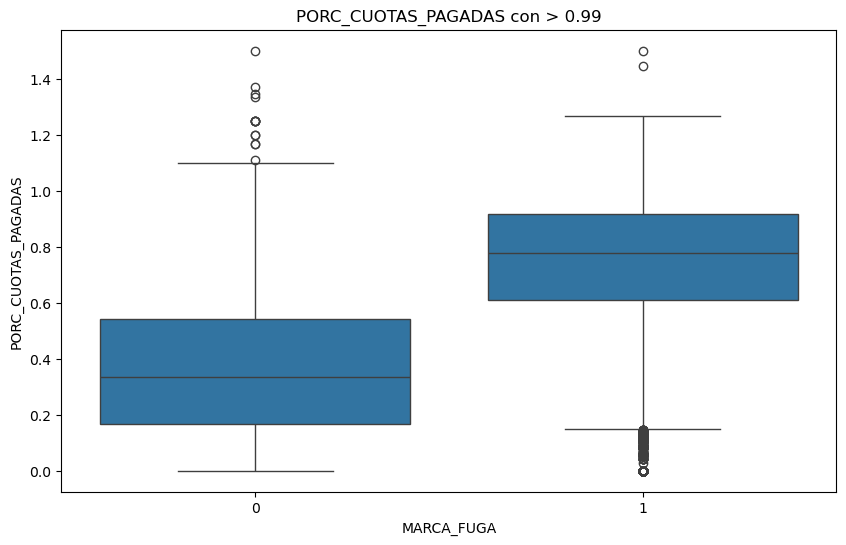

In [174]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df2, x='MARCA_FUGA', y='PORC_CUOTAS_PAGADAS')
# --- AQUÍ ESTÁ EL TRUCO ---
plt.ticklabel_format(style='plain', axis='y') 
plt.title('PORC_CUOTAS_PAGADAS con > 0.99')
# Si el saldo está en el eje X, cambia axis='y' por axis='x'
plt.show()

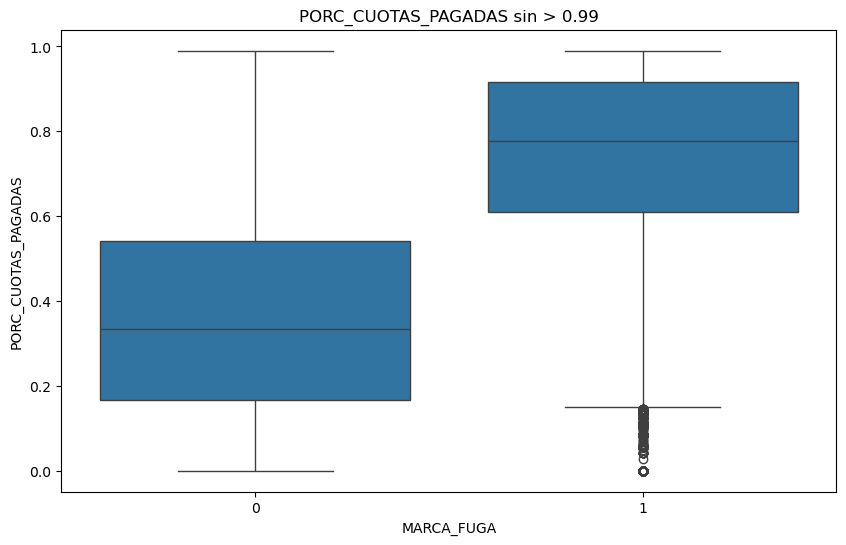

In [176]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df2, x='MARCA_FUGA', y='PORC_CUOTAS_PAGADAS')
# --- AQUÍ ESTÁ EL TRUCO ---
plt.ticklabel_format(style='plain', axis='y') 
plt.title('PORC_CUOTAS_PAGADAS sin > 0.99')
# Si el saldo está en el eje X, cambia axis='y' por axis='x'
plt.show()

In [28]:
# df2['PORC_CUOTAS_PAGADAS'].head()

0    0.229167
1    0.444444
2    0.000000
3    0.111111
4    0.333333
Name: PORC_CUOTAS_PAGADAS, dtype: float64

In [216]:
# Lista de niveles en el orden que quieres (de menor a mayor riesgo)
niveles = [['A', 'B', 'C', 'D', 'E']]
encoder = OrdinalEncoder(categories=niveles)
# Aplicamos al DataFrame (necesita doble corchete [[]])
df2['CALIFICACION'] = encoder.fit_transform(df2[['CALIFICACION']])

#
niveles2 = [['1. PERFIL_BUEN_CLIENTE', '2. PERFIL_MEDIO_CLIENTE', '3. PERFIL_MAL_CLIENTE']]
encoder2 = OrdinalEncoder(categories=niveles2)
df2['MARCA_CLIENTE'] = encoder2.fit_transform(df2[['MARCA_CLIENTE']])

In [217]:
cate = [['MASCULINO', 'FEMENINO']]
encoder2 = OrdinalEncoder(categories=cate)
df2['GENERO'] = encoder2.fit_transform(df2[['GENERO']])

In [218]:
print(df2[['MARCA_CLIENTE']].head())

   MARCA_CLIENTE
0            0.0
1            0.0
2            0.0
3            0.0
4            2.0


In [219]:
print(df2[df2['MARCA_CLIENTE'] == 1.0].head())

    SK_OFICINA  SK_CAMPAÑA   TASA  MORA  CALIFICACION  GARANTIA  \
24         221           0  44.46     0           0.0         1   
35         604           0  50.23     0           1.0         1   
44         288           0  48.54     0           0.0         1   
48         214           0  50.80    21           0.0         0   
58         257           0  50.33    28           0.0         0   

    SALDO_CAPITAL  MONTO_DESEMBOLSADO  NUMERO_CUOTAS  NUMERO_CUOTAS_PAGADAS  \
24     5279298.25           5296800.0             36                      2   
35     1592846.69           2550400.0             18                      9   
44     5941125.81           5999000.0             36                      3   
48     1954712.18           4115200.0             36                     24   
58     6100276.52          10239040.0             24                     12   

    ...  RT_SALDO_DESEMBOLSO  GENERO  IND_AGRO  COD_MUNICIPIO_CLIENTE  \
24  ...             0.996696     0.0         0   

In [81]:
# print(df2['CALIFICACION'].sort_values())

126357    0.0
126358    0.0
126359    0.0
126360    0.0
126363    0.0
         ... 
13        4.0
47        4.0
126364    4.0
126361    4.0
86        4.0
Name: CALIFICACION, Length: 126369, dtype: float64


In [60]:
# df.head(50)

In [221]:
#Dividiremos el conjunto de datos en característicias (features) y la variable objetivo (target)

# 'X' contiene todas las columnas numéricas EXCEPTO la que quieres predecir
X = df2.drop(columns=['MARCA_FUGA','CLIENTE_DIGITAL','SK_OFICINA','SK_CAMPAÑA','NUMERO_CUOTAS','CUOTAS_RESTANTES','CLIENTE_DIGITAL',
                      'NUMERO_CUOTAS_PAGADAS','MONTO_DESEMBOLSADO','GARANTIA','NOTA_CLIENTE','COD_MUNICIPIO_CLIENTE','RT_SALDO_DESEMBOLSO'])

# 'y' contiene solo la columna que quieres predecir
y = df2['MARCA_FUGA']

In [222]:
X.dtypes

TASA                   float64
MORA                     int64
CALIFICACION           float64
SALDO_CAPITAL          float64
GENERO                 float64
IND_AGRO                 int64
ENTIDADES_ALERTA       float64
MARCA_CLIENTE          float64
PORC_CUOTAS_PAGADAS    float64
dtype: object

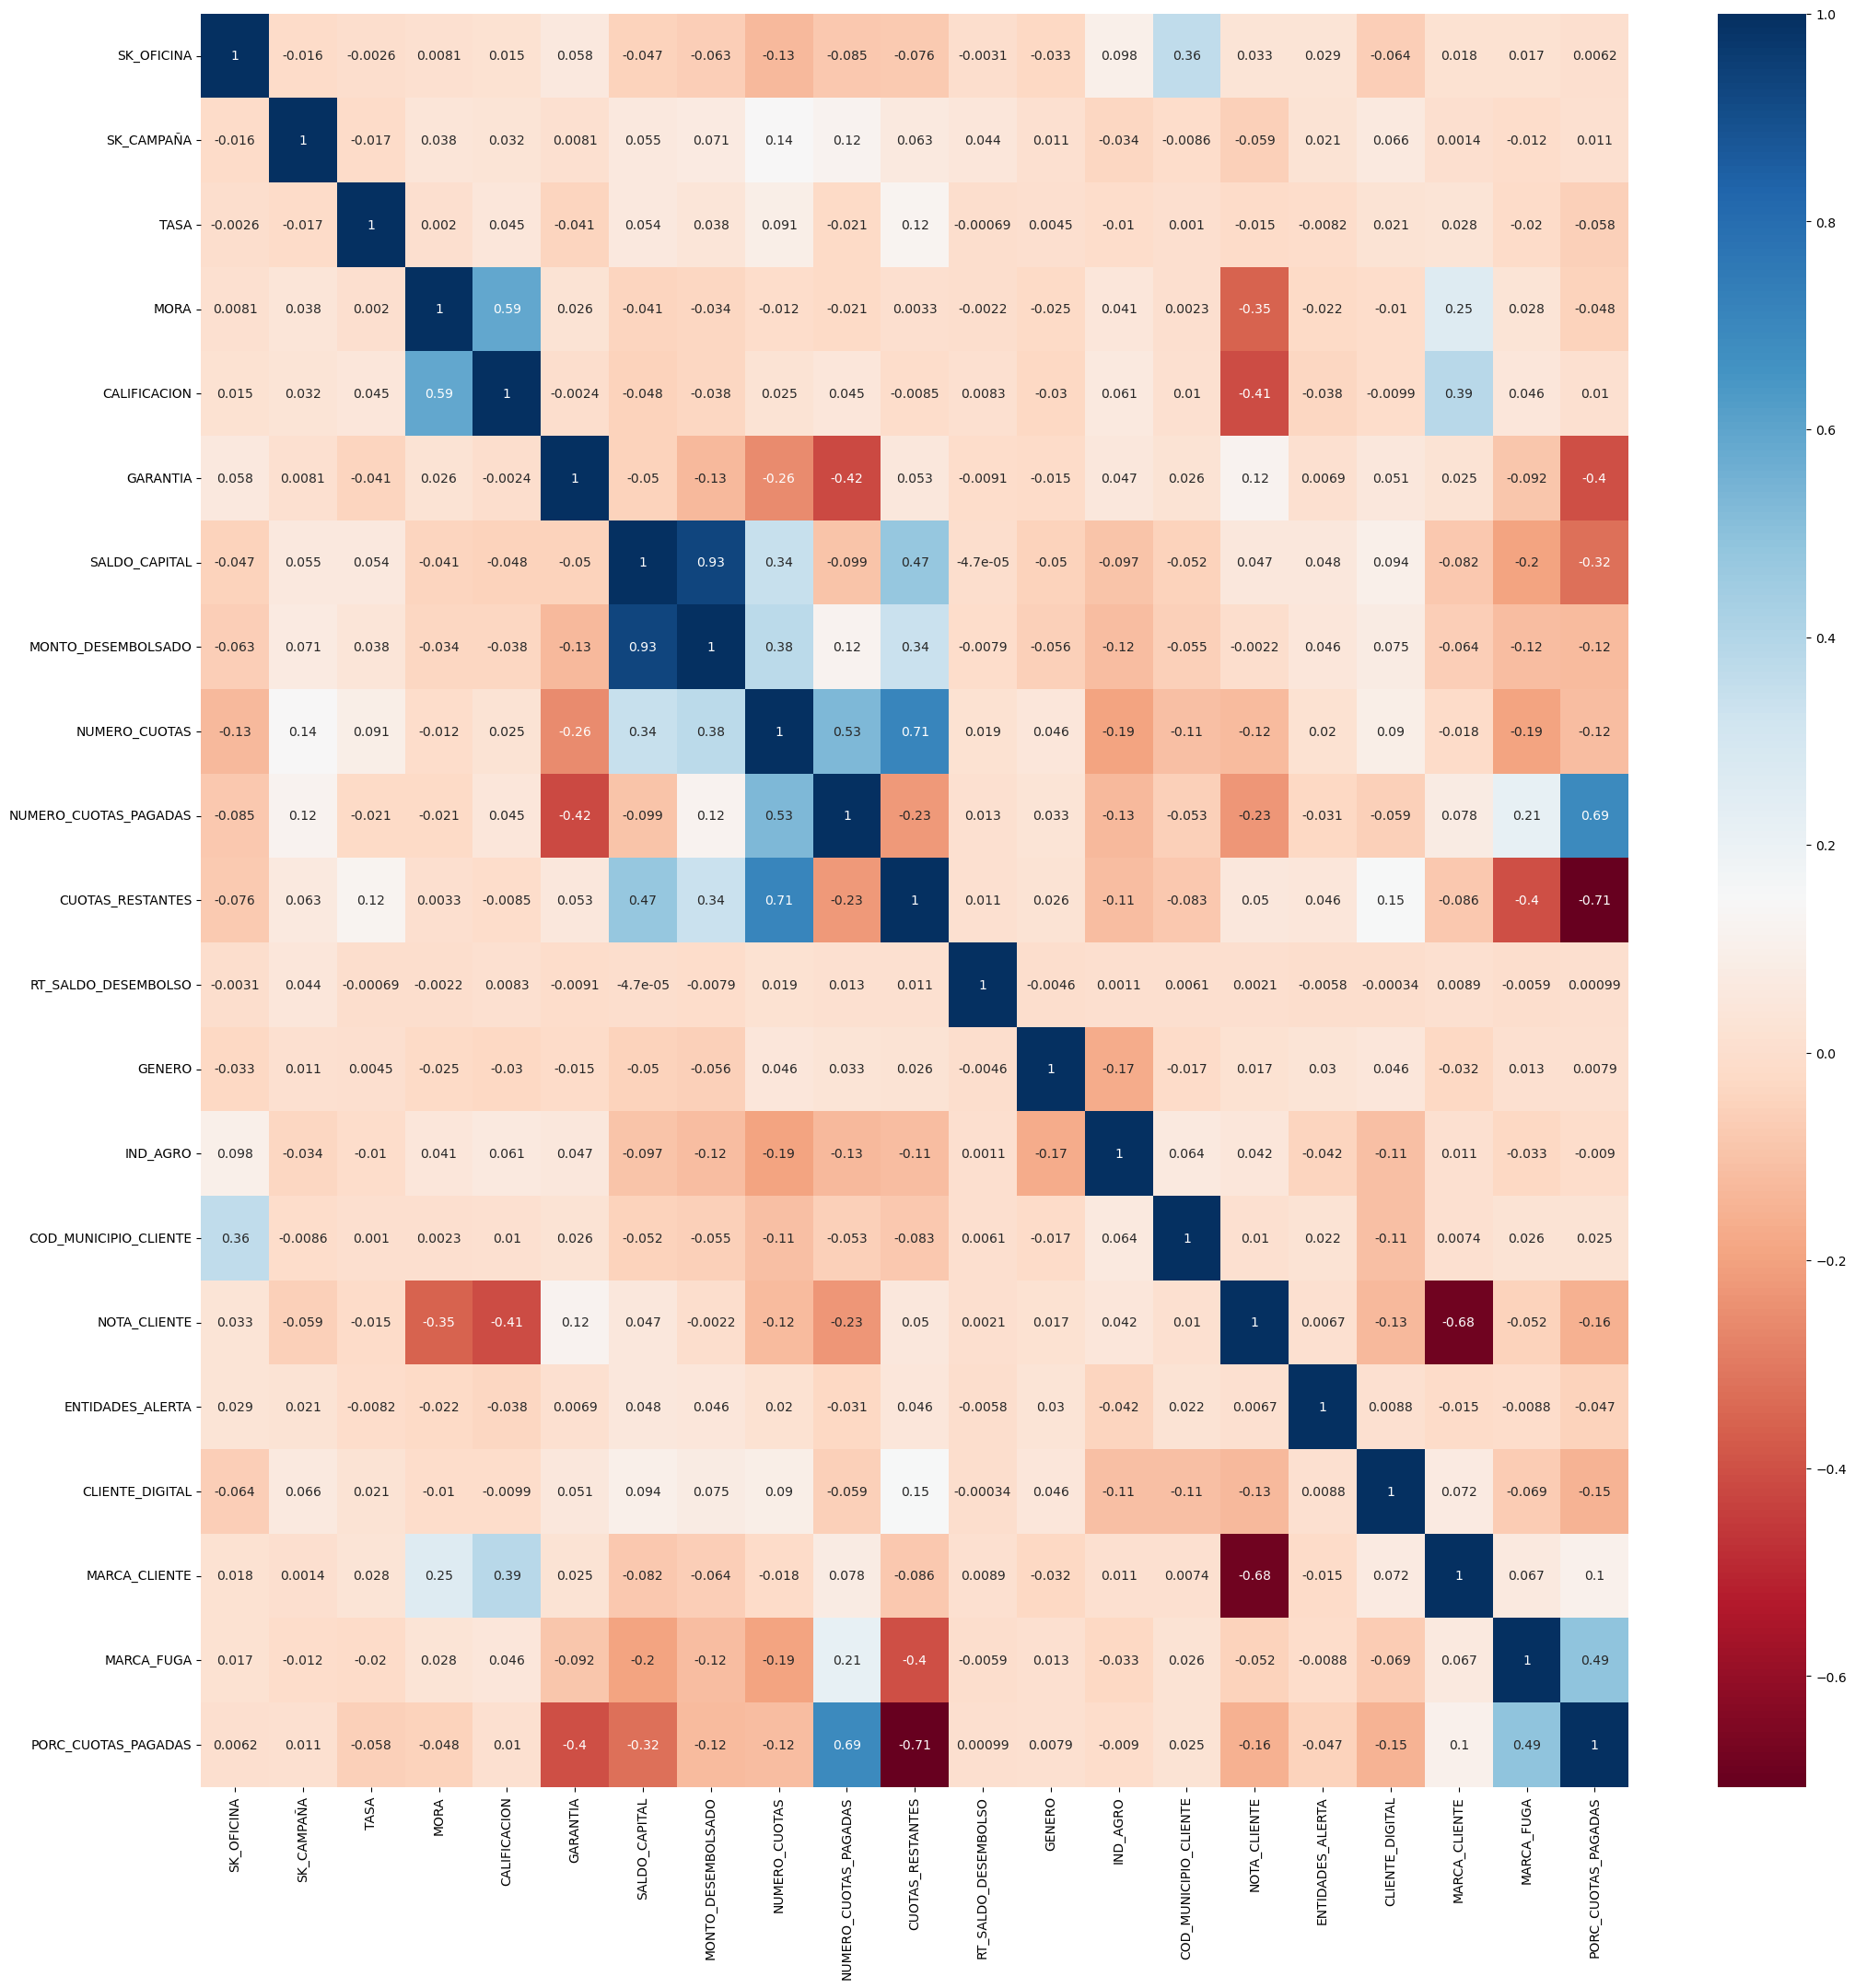

In [223]:
plt.figure(figsize=(25,25))
sns.heatmap(df2.select_dtypes(include=['int64', 'float64']).corr(), annot=True, cmap='RdBu')
plt.show()

## datos en entrenamiento y pruebas

##<p><strong>Paso: División del conjunto de datos en entrenamiento y pruebas </strong></br>
Para poder identificar la mejor parametrización de los algoritmos se usan diferentes estrategias. Una de ellas se llama Hold-Out y consiste en dejar un porcentaje para entrenar y otra para probar. Normalmente 60% para entrenar y 40% para probar.

In [183]:
# Dividir el conjunto de datos conjunto de entrenamiento y en conjunto de pruebas
# 70% entrenamiento y 30% prueba
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
 # 60% entrenamiento y 40% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=1)

##<p><strong>Paso: Entrenamiento y prueba del Arbol de Decision</strong></br>
 entrenamiento (X_train y Y_train) y luego haremos la predicción al conjunto de prueba (X_test)

# Entrenar el árbol de decisión
model = model.fit(X_train,y_train)

#Predecir la variable objetivo en los datos de prueba (probar el modelo)
y_pred = model.predict(X_test)

In [157]:
# Accuracy, permite identificar qué tan confiable es el modelo. Qué tantas predicciones correctas realizó? Se compara el valor original en y_test con el valor predicho en y_pred
print("Matriz de confusión: \n", confusion_matrix(y_test, y_pred))

print("Matriz de confusión normalizada: \n", confusion_matrix(y_test, y_pred, normalize="true"))
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print("TN,FP,FN,TP \n", (tn, fp, fn, tp))

Matriz de confusión: 
 [[37220  3939]
 [ 2265  7124]]
Matriz de confusión normalizada: 
 [[0.90429797 0.09570203]
 [0.24123975 0.75876025]]
TN,FP,FN,TP 
 (np.int64(37220), np.int64(3939), np.int64(2265), np.int64(7124))


In [158]:
# Ahora calcularemos las métricas derivadas de la matriz de confusión
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.90      0.92     41159
           1       0.64      0.76      0.70      9389

    accuracy                           0.88     50548
   macro avg       0.79      0.83      0.81     50548
weighted avg       0.89      0.88      0.88     50548



##<p><strong>Paso: Visualización </strong></br>
 Visualizaremos el árbol de decisión

In [198]:
#Primero visualizaremos el número de nodos
n_nodes = model.tree_.node_count
print("El árbol construido tiene ", n_nodes, "nodos ")
#Ahora visualizaremos el árbol en modo texto
arbol = tree.export_text(model, feature_names=X.columns.tolist(), show_weights=True)
print(arbol)

El árbol construido tiene  193 nodos 
|--- PORC_CUOTAS_PAGADAS <= 0.66
|   |--- SALDO_CAPITAL <= 1233417.38
|   |   |--- PORC_CUOTAS_PAGADAS <= 0.56
|   |   |   |--- MORA <= 18.50
|   |   |   |   |--- PORC_CUOTAS_PAGADAS <= 0.44
|   |   |   |   |   |--- TASA <= 52.50
|   |   |   |   |   |   |--- SALDO_CAPITAL <= 744890.00
|   |   |   |   |   |   |   |--- weights: [55.16, 40.72] class: 0
|   |   |   |   |   |   |--- SALDO_CAPITAL >  744890.00
|   |   |   |   |   |   |   |--- weights: [858.04, 198.17] class: 0
|   |   |   |   |   |--- TASA >  52.50
|   |   |   |   |   |   |--- PORC_CUOTAS_PAGADAS <= 0.26
|   |   |   |   |   |   |   |--- weights: [188.77, 73.30] class: 0
|   |   |   |   |   |   |--- PORC_CUOTAS_PAGADAS >  0.26
|   |   |   |   |   |   |   |--- weights: [9.19, 38.01] class: 1
|   |   |   |   |--- PORC_CUOTAS_PAGADAS >  0.44
|   |   |   |   |   |--- TASA <= 56.69
|   |   |   |   |   |   |--- weights: [307.67, 230.75] class: 0
|   |   |   |   |   |--- TASA >  56.69
|   |   | 

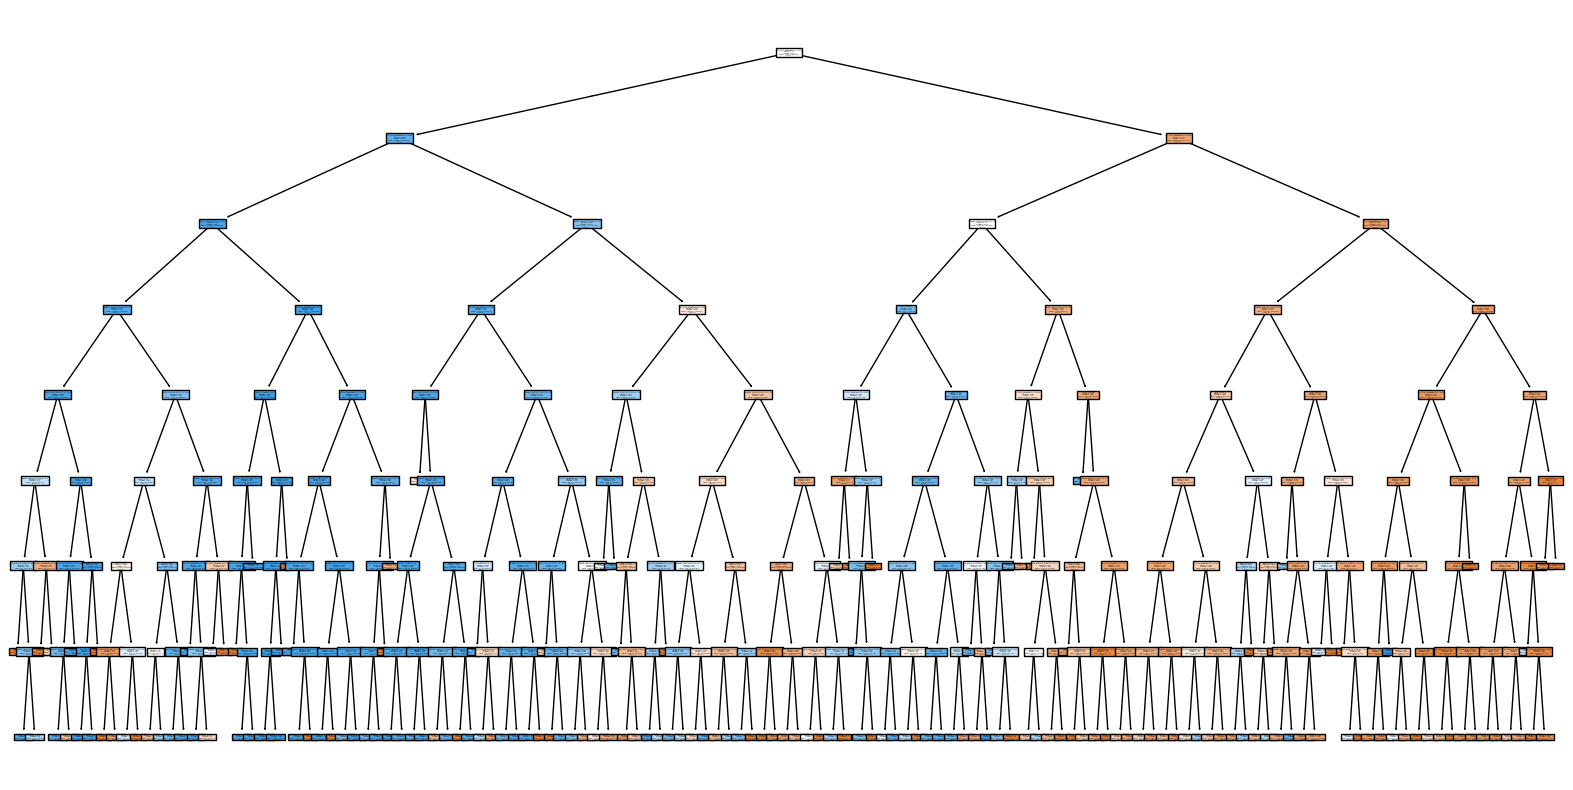

In [214]:
#Ahora visualizaremos el árbol gráficamente
plt.figure(figsize=(20,10))
tree.plot_tree(model,
               feature_names=X.columns.tolist(),
               class_names=['0','1'],
               filled=True)
plt.show()

##<p><strong>Paso: Probando otros parámetros para crear el árbol</strong></br>
Hasta el momento generamos el árbol sin revisar muy bien la parametrización. Si modificamos el criterio de partición y la profundidad máxima permitida se obtendrá un desempeño diferente
Para mayor información de los parámetros consultar <a href="https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier" target="_blank">Documentación Decision Tree Clasifier</a>

In [184]:
# Crear el objeto árbol de decisión
model2 = DecisionTreeClassifier(random_state=5, criterion="entropy", class_weight="balanced")

# Entrenar el árbol
model2 = model2.fit(X_train,y_train)

# Predecir los valores del conjunto de prueba
y_pred = model2.predict(X_test)


In [185]:
#Calcularemos nuevamente las medidas de desempeño
# Accuracy, permite identificar qué tan confiable es el modelo. Qué tantas predicciones correctas realizó? Se compara el valor original en y_test con el valor predicho en y_pred
print("Matriz de confusión: \n", confusion_matrix(y_test, y_pred))
print("Matriz de confusión normalizada: \n", confusion_matrix(y_test, y_pred, normalize="true"))
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print("TN,FP,FN,TP \n", (tn, fp, fn, tp))

# Ahora calcularemos las métricas derivadas de la matriz de confusión
print(classification_report(y_test, y_pred))

Matriz de confusión: 
 [[37010  4149]
 [ 4305  5084]]
Matriz de confusión normalizada: 
 [[0.8991958  0.1008042 ]
 [0.45851528 0.54148472]]
TN,FP,FN,TP 
 (np.int64(37010), np.int64(4149), np.int64(4305), np.int64(5084))
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     41159
           1       0.55      0.54      0.55      9389

    accuracy                           0.83     50548
   macro avg       0.72      0.72      0.72     50548
weighted avg       0.83      0.83      0.83     50548



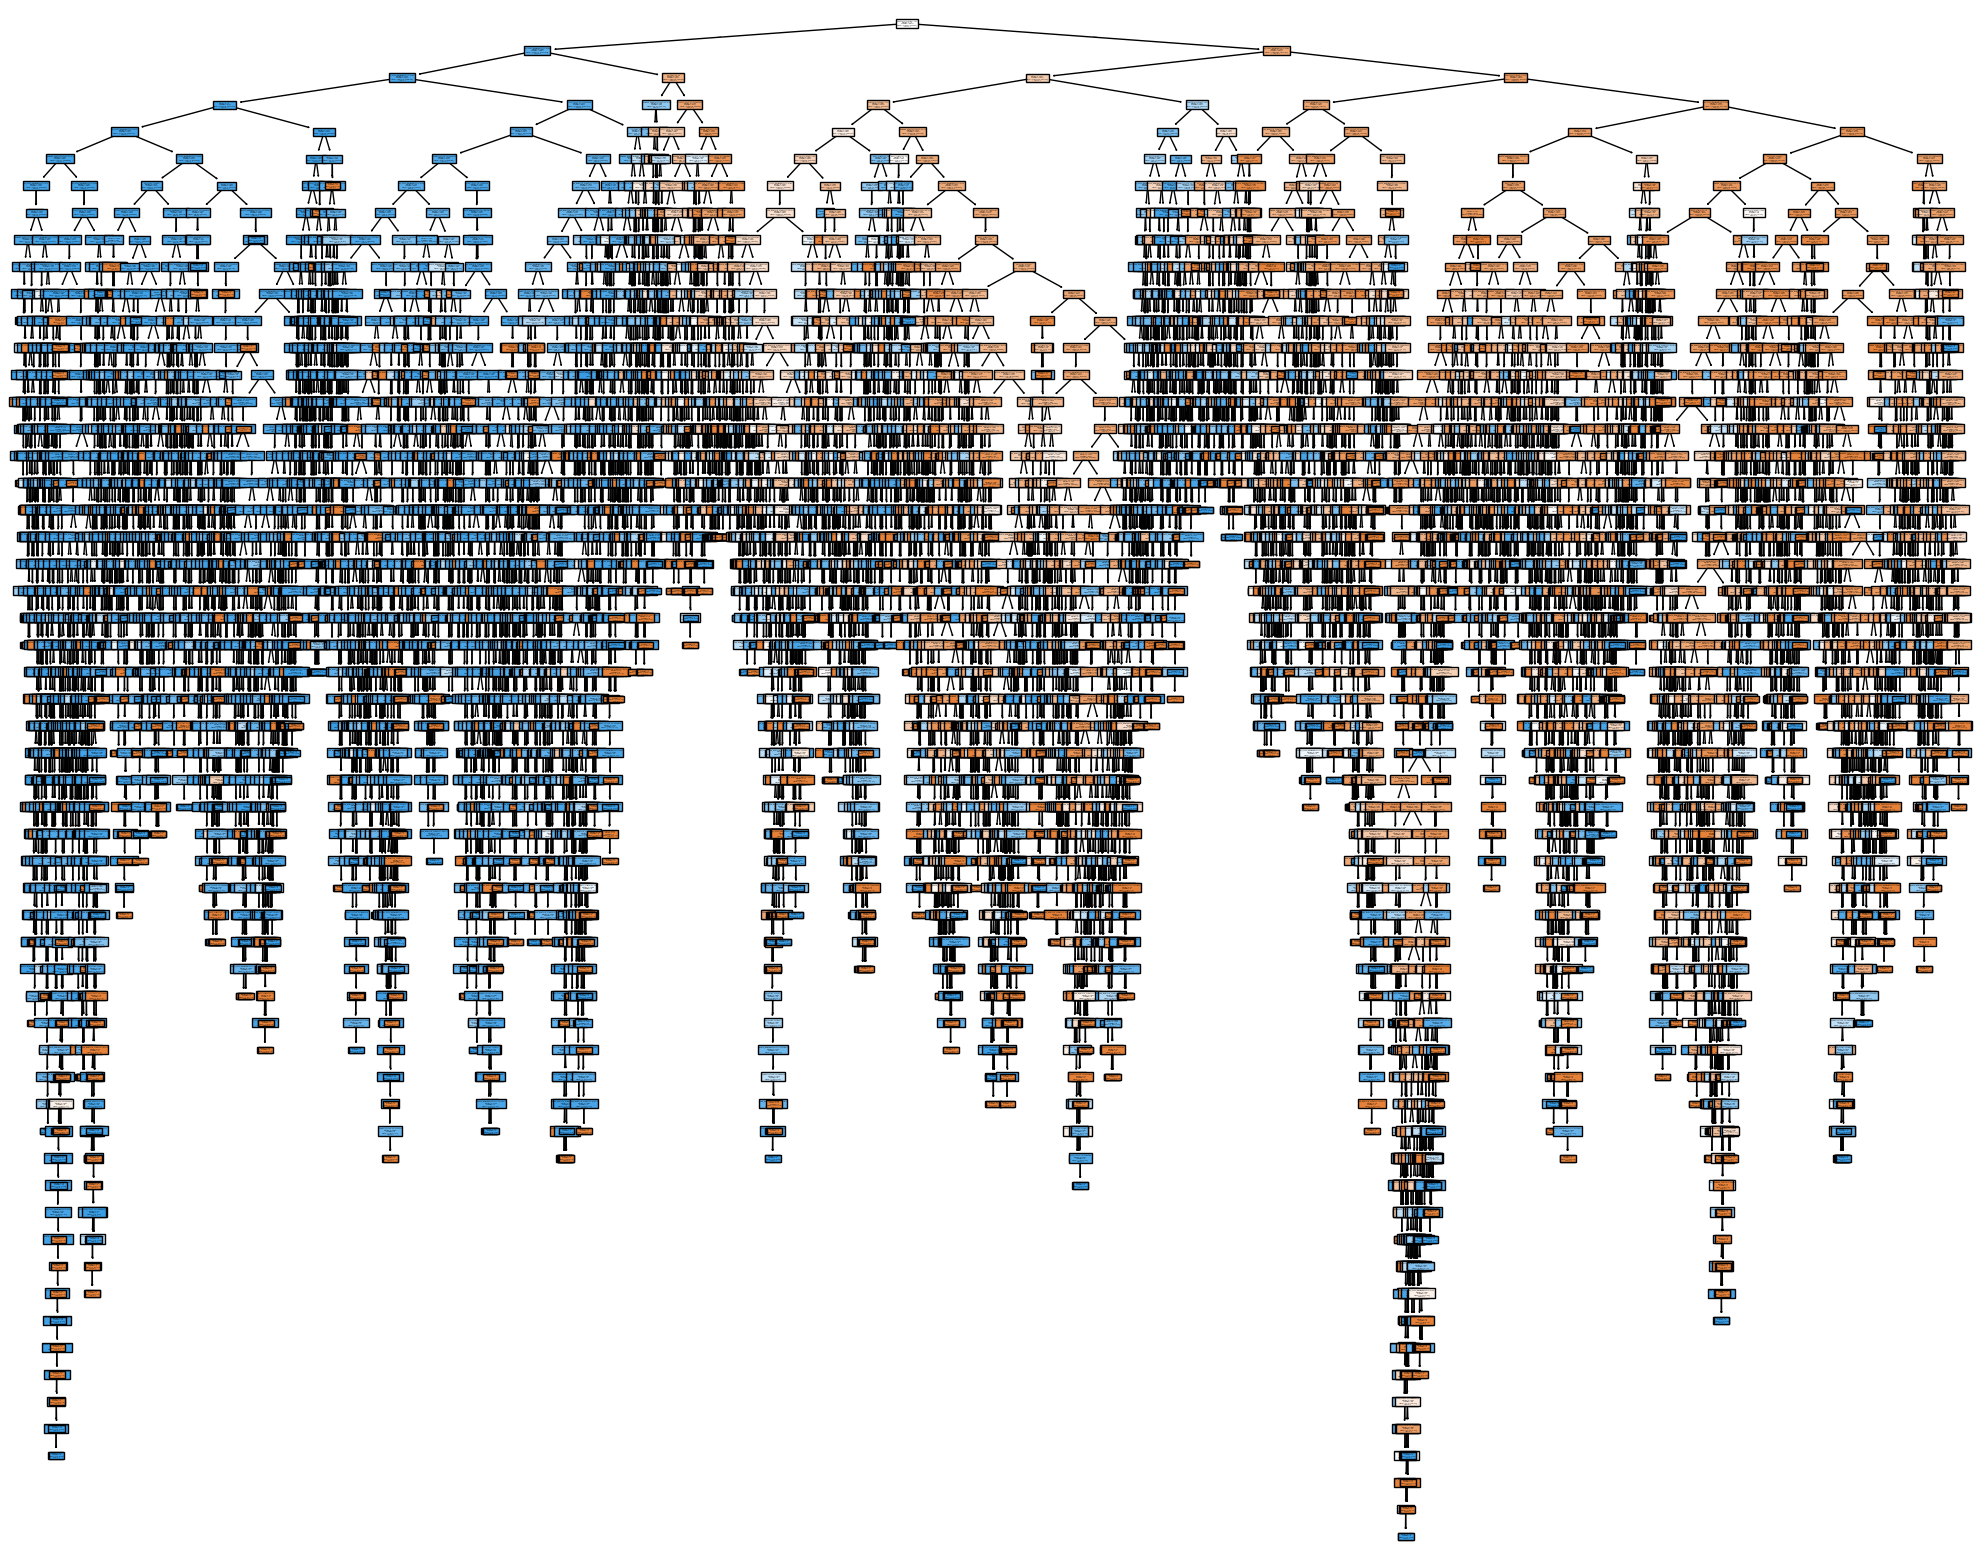

In [113]:
#Ahora visualizaremos el árbol gráficamente
plt.figure(figsize=(25,20))
tree.plot_tree(model2,
               feature_names=X.columns.tolist(),
               class_names=['0','1'],
               filled=True)
plt.show()

# pre-poda

##<p><strong>Paso: Podar para evitar sobreajuste o sobre alimentación </strong></br>
Las métricas de desempeño parecían interesantes. Sin embargo, al observar el árbol podemos identificar un claro sobre ajuste pues tenemos muchos niveles y, considerando que el número de atributos es pequeño, es un fuerte indicio de estar generando prácticamente una regla por cada registro (ejemplo). Es necesario aplicar diferentes mecanismos para evitar el sobre ajuste. El más relevante es la poda.


In [186]:
# Crear el objeto árbol de decisión
model = DecisionTreeClassifier(random_state=5, criterion="entropy", class_weight="balanced", min_samples_leaf=20, max_depth=7)

# Entrenar el árbol
model = model.fit(X_train,y_train)

# Predecir los valores del conjunto de prueba
y_pred = model.predict(X_test)

#Evaluemos el desempeño del nuevo árbol
print("Accuracy: \n", metrics.accuracy_score(y_test, y_pred))

Accuracy: 
 0.87057846007755


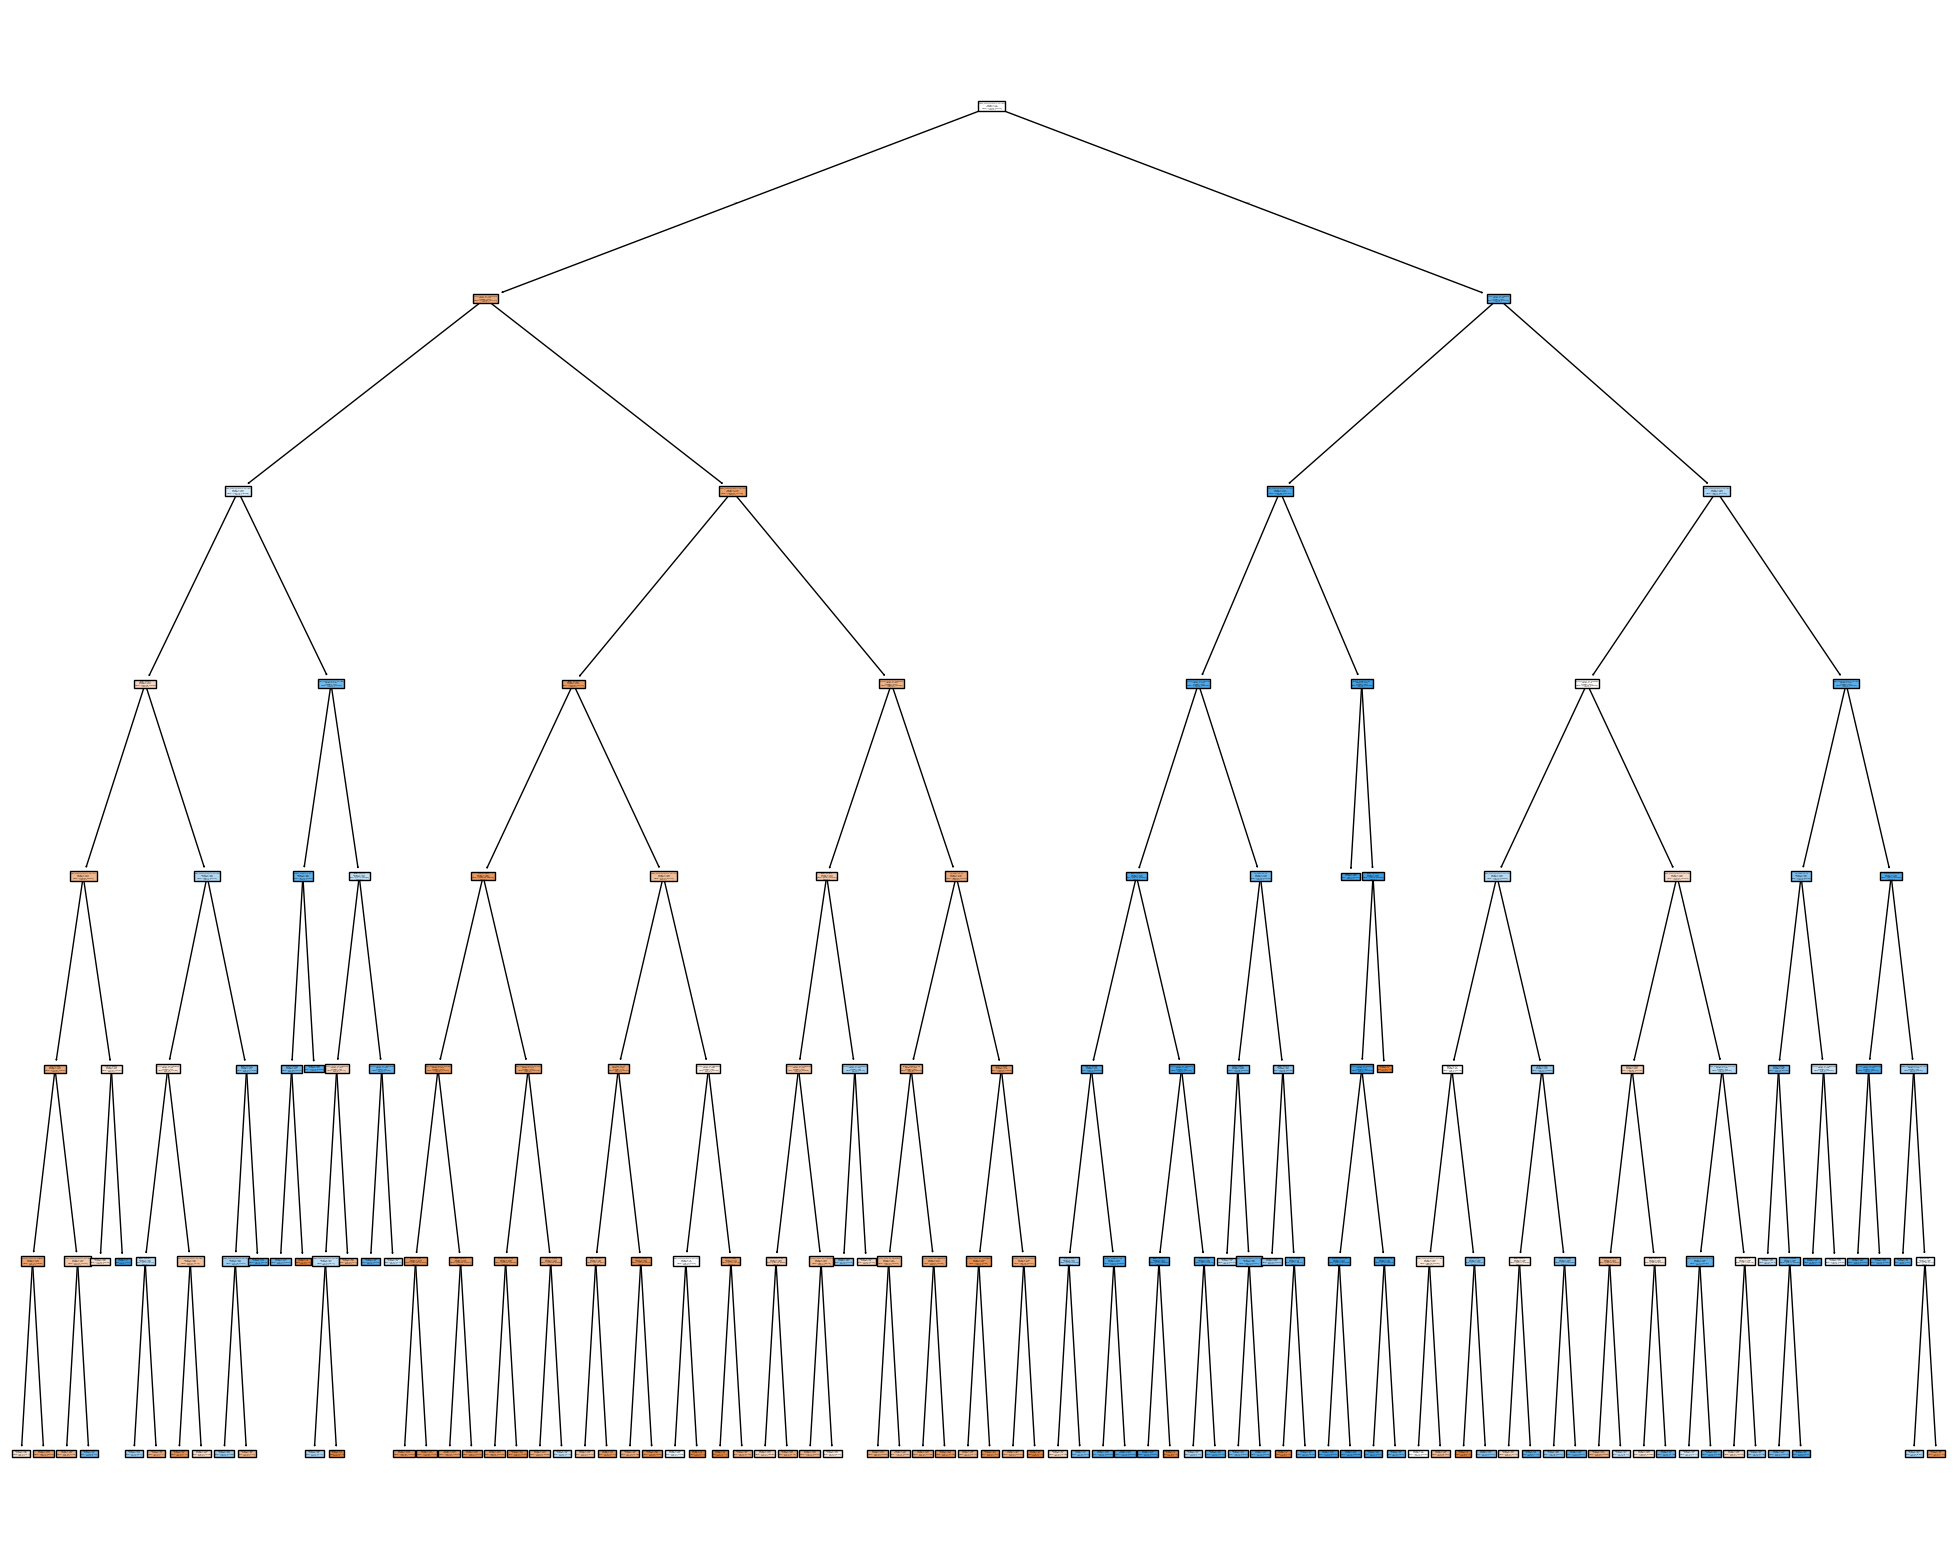

In [197]:
#Ahora visualizaremos el árbol gráficamente
plt.figure(figsize=(25,20))
tree.plot_tree(model,
               feature_names=X.columns.tolist(),
               class_names=['0','1'],
               filled=True)
plt.show()

In [196]:
#Para poder ver mejor los nodos lo visualizaremos en modo texto
arbol = tree.export_text(model, feature_names=X.columns.tolist(), show_weights=True)
print(arbol)

|--- PORC_CUOTAS_PAGADAS <= 0.66
|   |--- SALDO_CAPITAL <= 1233417.38
|   |   |--- PORC_CUOTAS_PAGADAS <= 0.56
|   |   |   |--- MORA <= 18.50
|   |   |   |   |--- PORC_CUOTAS_PAGADAS <= 0.44
|   |   |   |   |   |--- TASA <= 52.50
|   |   |   |   |   |   |--- SALDO_CAPITAL <= 744890.00
|   |   |   |   |   |   |   |--- weights: [55.16, 40.72] class: 0
|   |   |   |   |   |   |--- SALDO_CAPITAL >  744890.00
|   |   |   |   |   |   |   |--- weights: [858.04, 198.17] class: 0
|   |   |   |   |   |--- TASA >  52.50
|   |   |   |   |   |   |--- PORC_CUOTAS_PAGADAS <= 0.26
|   |   |   |   |   |   |   |--- weights: [188.77, 73.30] class: 0
|   |   |   |   |   |   |--- PORC_CUOTAS_PAGADAS >  0.26
|   |   |   |   |   |   |   |--- weights: [9.19, 38.01] class: 1
|   |   |   |   |--- PORC_CUOTAS_PAGADAS >  0.44
|   |   |   |   |   |--- TASA <= 56.69
|   |   |   |   |   |   |--- weights: [307.67, 230.75] class: 0
|   |   |   |   |   |--- TASA >  56.69
|   |   |   |   |   |   |--- weights: [0.00, 13.

##<p><strong>Paso: Optimizando los hiperparámetros del modelo</strong><br>
Probar cuáles son los mejores parámetros para el modelo es muy dispendioso. Afortunadamene hay librerías que nos ayudan en esta labor.

In [187]:
#Función para optimizar los parámetros de un árbol de decisión
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

def dtree_grid_search(X,y,nfolds,n_jobs=-1):
    #crear un diccionario con todos los valores que se quieren probar
    param_grid = { 'criterion':['gini','entropy'],'max_depth': np.arange(3, 15), 'min_samples_split': np.arange(20, 30)  }
    # Crear el objeto árbol de decisión
    dtree_model=DecisionTreeClassifier()
    #use gridsearch para probar todos los valores
    dtree_gscv = GridSearchCV(dtree_model, param_grid, cv=nfolds)
    #entrenaremos
    dtree_gscv.fit(X, y)
    return dtree_gscv.best_params_

In [188]:
#Acá llamaremos la función para calcular los mejores parámetros
bestparam = dtree_grid_search(X_train,y_train,4)
print ("Los mejores parámetros son", bestparam)

Los mejores parámetros son {'criterion': 'entropy', 'max_depth': np.int64(7), 'min_samples_split': np.int64(20)}


In [189]:
# Crear el árbol de decisión con los mejores parámetros el ** es para desempaquetar el objeto dict (diccionario).
model = DecisionTreeClassifier(**bestparam, random_state=5, class_weight="balanced")

# Entrenar el árbol
model = model.fit(X_train,y_train)

#Predecir los valores del conjunto de entrenamiento
y_pred = model.predict(X_test)

# Calcular el accuracy
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.8699651816095593


#  Pos-Poda con ccp_alpha

In [190]:
# El parámetro de complejidad de costos, ccp_alpha permite podar el árbol. Mayores valores de ccp_alpha aumentan el número de nodos podados
# Para identificar el valor más apropiado, graficaremos el accuracy en prueba y en entrenamiento, para ver en cuál valor de complejidad se alcanza el mejor accuracy en pruebas
path = model.cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas
accuracy_train, accuracy_test=[],[]
max_testAccuracy = 0
for i in alphas:
  model=DecisionTreeClassifier(ccp_alpha=i)
  model = model.fit(X_train,y_train)
  y_train_pred=model.predict(X_train)
  y_test_pred=model.predict(X_test)
  accuracy_train.append(metrics.accuracy_score(y_train, y_train_pred))
  accuracy_test.append(metrics.accuracy_score(y_test, y_test_pred))
  #Identificaremos cuál es el valor del alpha que más aumenta el accuracy en el set de pruebas
  if (max_testAccuracy < metrics.accuracy_score(y_test, y_test_pred)):
    max_testAccuracy = metrics.accuracy_score(y_test, y_test_pred)
    selectedlAlpha = i
selectedlAlpha

np.float64(0.00010149629277399642)

In [192]:
# Crearemos el último árbol con los mejores parámetros detectados y el valor de alpha detectado como el mejor para aumentar el accuracy
model = DecisionTreeClassifier(**bestparam, random_state = 6, class_weight = "balanced", ccp_alpha = selectedlAlpha)
model = model.fit(X_train,y_train)
y_train_pred=model.predict(X_train)
y_test_pred=model.predict(X_test)
print("El accuracy de entrenamiento es: ", metrics.accuracy_score(y_train, y_train_pred), "y el de pruebas es: ", metrics.accuracy_score(y_test, y_test_pred))

# Ahora calcularemos las métricas derivadas de la matriz de confusión

# print(classification_report(y_test, y_pred))


# 1. Obtener las probabilidades de la clase 1 (Fuga)
# predict_proba devuelve [prob_clase_0, prob_clase_1]
y_probs = model.predict_proba(X_test)[:, 1]

# 2. Aplicar el nuevo umbral de 0.60
y_test_pred_70 = (y_probs >= 0.7).astype(int)

# 3. Ver los resultados con el nuevo umbral
print("--- Reporte con Umbral 0.70 ---")
print(classification_report(y_test, y_test_pred_70))

El accuracy de entrenamiento es:  0.8742564724812387 y el de pruebas es:  0.870182796549814
--- Reporte con Umbral 0.70 ---
              precision    recall  f1-score   support

           0       0.93      0.92      0.93     41159
           1       0.68      0.71      0.69      9389

    accuracy                           0.88     50548
   macro avg       0.80      0.81      0.81     50548
weighted avg       0.88      0.88      0.88     50548



 - Ajuste del Umbral de Clasificación (o Classification Threshold Adjustment).

- Optimización del Umbral (Threshold Tuning): Es el proceso de mover el punto de decisión (que por defecto es 0.5) para adaptar el modelo a las necesidades del negocio.
Búsqueda del Punto de Operación (Operating Point): Estás eligiendo en qué parte de la curva (ROC o Precision-Recall) quieres que trabaje tu modelo. Al elegir 0.7, definiste tu "punto de operación" óptimo.
Post-procesamiento de Probabilidades: Se llama así porque no estás cambiando el entrenamiento del modelo, sino manipulando su salida (output) para obtener un resultado diferente.


- Se hace para gestionar el Trade-off (Intercambio) entre Precisión y Recall. sacrificar un poco de Recall para ganar Precisión, moviéndose hacia un modelo más "conservador" que genera menos falsas alarmas.

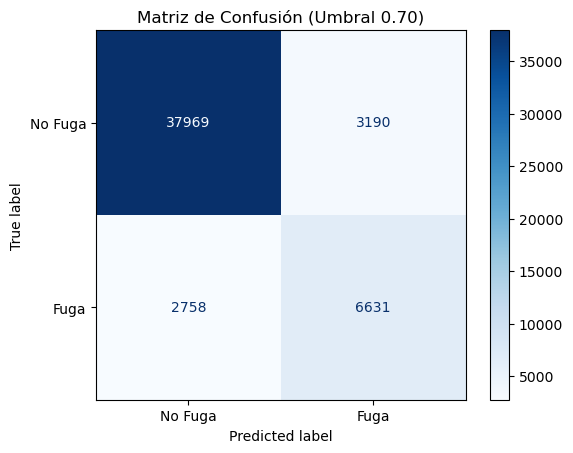

Falsas alarmas (Clientes que NO se iban): 3190
Fugas no detectadas (Clientes que SE FUERON y no vimos): 2758
Fugas detectadas con éxito: 6631


In [193]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Usamos las predicciones del umbral 0.70
cm = confusion_matrix(y_test, y_test_pred_70)

# Visualización
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Fuga', 'Fuga'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión (Umbral 0.70)')
plt.show()

# Para ver los números exactos en texto:
tn, fp, fn, tp = cm.ravel()
print(f"Falsas alarmas (Clientes que NO se iban): {fp}")
print(f"Fugas no detectadas (Clientes que SE FUERON y no vimos): {fn}")
print(f"Fugas detectadas con éxito: {tp}")

In [212]:
# from sklearn.metrics import precision_recall_curve, roc_curve, auc
# import matplotlib.pyplot as plt

# 1. Calcular los valores para ambas curvas
# Usamos y_probs (las probabilidades que ya calculaste)
# fpr, tpr, _ = roc_curve(y_test, y_probs)
# roc_auc = auc(fpr, tpr)

# precision, recall, _ = precision_recall_curve(y_test, y_probs)
# pr_auc = auc(recall, precision)

# # 2. Graficar
# fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# # Gráfico ROC
# ax[0].plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
# ax[0].plot([0, 1], [0, 1], color='navy', linestyle='--')
# ax[0].set_title('Curva ROC')
# ax[0].set_xlabel('Tasa de Falsos Positivos')
# ax[0].set_ylabel('Tasa de Verdaderos Positivos (Recall)')
# ax[0].legend()

# # Gráfico Precision-Recall
# ax[1].plot(recall, precision, color='green', label=f'PR curve (area = {pr_auc:.2f})')
# ax[1].set_title('Curva Precision-Recall')
# ax[1].set_xlabel('Recall')
# ax[1].set_ylabel('Precision')
# ax[1].legend()

# plt.show()

In [194]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score

# Definir los umbrales que queremos probar
umbrales = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]

resultados = []

for u in umbrales:
    # Aplicar el umbral a las probabilidades
    preds = (y_probs >= u).astype(int)
    
    # Calcular métricas para la clase 1 (Fuga)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = 2 * (prec * rec) / (prec + rec)
    
    resultados.append({
        'Umbral': u,
        'Precisión (Clase 1)': round(prec, 3),
        'Recall (Clase 1)': round(rec, 3),
        'F1-Score': round(f1, 3)
    })

# Mostrar la tabla comparativa
df_comparativo = pd.DataFrame(resultados)
print(df_comparativo)

   Umbral  Precisión (Clase 1)  Recall (Clase 1)  F1-Score
0    0.50                0.627             0.743     0.680
1    0.55                0.644             0.733     0.686
2    0.60                0.649             0.731     0.687
3    0.65                0.657             0.725     0.689
4    0.70                0.675             0.706     0.690
5    0.75                0.698             0.680     0.689
6    0.80                0.725             0.632     0.675
7    0.85                0.727             0.630     0.675
8    0.90                0.788             0.470     0.589


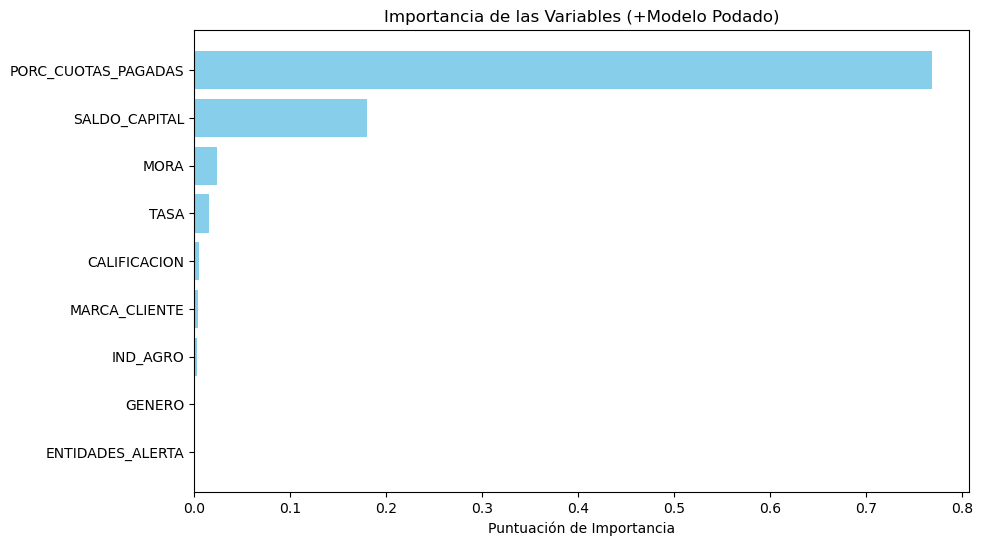

              Variable  Importancia
8  PORC_CUOTAS_PAGADAS     0.769378
3        SALDO_CAPITAL     0.180433
1                 MORA     0.023501
0                 TASA     0.015737
2         CALIFICACION     0.004655
7        MARCA_CLIENTE     0.003366
5             IND_AGRO     0.002929
4               GENERO     0.000000
6     ENTIDADES_ALERTA     0.000000


In [195]:
# Crear un DataFrame con los resultados
importancias = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# Visualizar
plt.figure(figsize=(10, 6))
plt.barh(importancias['Variable'], importancias['Importancia'], color='skyblue')
plt.gca().invert_yaxis() # Para que la más importante salga arriba
plt.title('Importancia de las Variables (+Modelo Podado)')
plt.xlabel('Puntuación de Importancia')
plt.show()

# Mostrar el top n por consola
print(importancias.head(50))

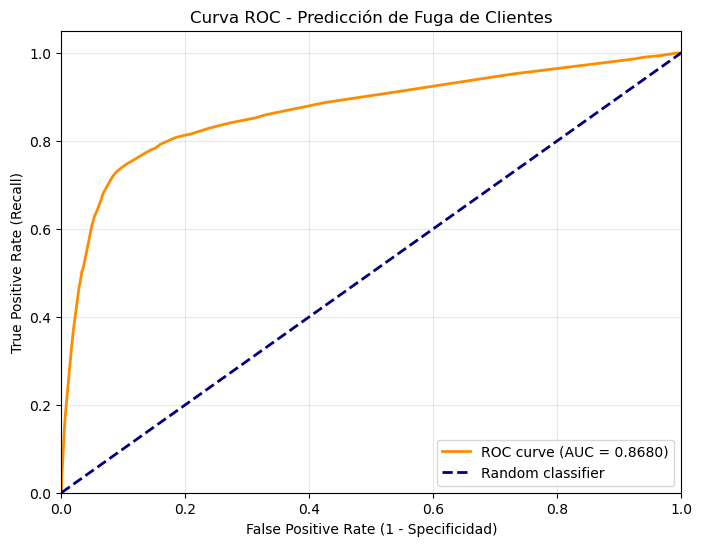

Umbral óptimo (Índice de Youden): 0.5311
TPR en umbral óptimo: 0.7426
FPR en umbral óptimo: 0.1007


In [225]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificidad)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Curva ROC - Predicción de Fuga de Clientes')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# También útil: encontrar el umbral óptimo de Youden
youden_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[youden_idx]
print(f"Umbral óptimo (Índice de Youden): {optimal_threshold:.4f}")
print(f"TPR en umbral óptimo: {tpr[youden_idx]:.4f}")
print(f"FPR en umbral óptimo: {fpr[youden_idx]:.4f}")

# 0.80-0.90 modelo dentro del rango ROC AUC

## MODELO Otro